# Hackathon

Métodos para el Análisis de Datos

Pilar Maiztegui

**Descripción del desafío:**

El Municipio de Bahía Blanca publica en su portal de Gobierno Abierto las órdenes de compra emitidas cada año.
En este hackathon vamos a trabajar con un dataset de los que hay disponibles, que contiene 8.559 registros.
Nuestro desafío es construir un modelo de regresión que prediga el importe de una orden de compra a partir de las variables disponibles, aplicando los métodos estudiados en MAD1.

**Checkpoint obligatorio**

Entrando a https://datos.bahia.gob.ar/dataset/compras, descargamos el dataset llamado "Compras Ejercicio 2024" en formato csv. 

Importemos el dataset y chequeemos si es el correcto verificando el siguiente enunciado:
*"El 6 de agosto de 2024, el proveedor NUGGETS realizó una venta a la Subsecretaría de Niñez, Adolescencia y Familia. ¿Cuál fue el importe de esa orden de compra?"*

In [1]:
import pandas as pd
df=pd.read_csv("ordenes_de_compras_municipales-2024.csv")

In [2]:
# 1. Aseguramos que la fecha sea tipo datetime para evitar errores de formato
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Buscamos solo por FECHA y PROVEEDOR (que son los datos más únicos)
busqueda = df[
    (df['fecha'] == '2024-08-06') & 
    (df['proveedor'].str.contains('NUGGETS', case=False, na=False))
]

# 3. Verificamos qué encontramos
if not busqueda.empty:
    print(busqueda[['fecha', 'proveedor', 'dependencia', 'importe']])

          fecha proveedor                            dependencia   importe
3471 2024-08-06   NUGGETS  SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA  227601.0


C:\Users\tetep\AppData\Local\Temp\ipykernel_15704\3907091220.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha'] = pd.to_datetime(df['fecha'])


Luego, la orden de compra del proveedor NUGGETS el 06-08-2024 fue de $227601

# *Exploración y limpieza*

Veamos las primeras lineas.

In [4]:
df.head(10)

,ejercicio,ordencompra,fecha,importe,proveedor,dependencia,expediente
0,2024,7486,2024-10-21,3.477154e+04,PROMAR S.R. L,DIRECCION GENERAL DE EDUCACION,Suministro 7507/2024
1,2024,7497,2024-10-22,2.815000e+08,SOLUCIONES TURISTICAS SRL.,INSTITUTO DEL DEPORTE,Suministro 5536/2024
2,2024,307,2024-01-30,7.435440e+05,NAVARRETE YAMILA MALENA,SEC. DE OBRAS Y SERVICIOS PUBLICOS,Suministro 393/2024
3,2024,1739,2024-03-25,2.050000e+05,ACQUAMANSA,TEATRO MUNICIPAL,Suministro 2210/2024
4,2024,2991,2024-05-15,1.933479e+05,CODIMAT S.A.,DIRECCION GENERAL DE DISCAPACIDAD Y ACCESIBILIDAD,Suministro 3344/2024
5,2024,434,2024-02-07,1.250000e+06,CACU CLIMATIZACION,SEC. DE SALUD,Suministro 402/2024
6,2024,7013,2024-09-30,1.050000e+06,COPYFAX FOTOCOPIADORAS S.R.L.,TRIBUNAL DE FALTAS,Suministro 7082/2024
7,2024,7617,2024-10-25,1.635000e+05,GRUPO BAHIA BLANCA,DEPARTAMENTO TALLERES Y MAESTRANZA,Suministro 7645/2024
8,2024,7659,2024-10-29,1.155000e+06,MEDICA BAHIA,SEC. DE SALUD,Suministro 7665/2024
9,2024,896,2024-02-29,5.857750e+05,GAVILAN MONICA PATRICIA,MAMAS CUIDADORAS,Suministro 1026/2024


Veamos estadísticas descriptivas.

In [6]:
df.describe()

,ejercicio,ordencompra,fecha,importe
count,8559.0,8559.000000,8559,8.559000e+03
mean,2024.0,4444.825797,2024-07-02 20:30:01.892744,7.366996e+06
min,2024.0,1.000000,2024-01-02 00:00:00,4.200000e+02
25%,2024.0,2227.500000,2024-04-11 00:00:00,2.190050e+05
50%,2024.0,4434.000000,2024-06-28 00:00:00,6.561041e+05
75%,2024.0,6646.500000,2024-09-20 00:00:00,1.696600e+06
max,2024.0,9581.000000,2024-12-31 00:00:00,5.786833e+09
std,0.0,2568.933889,NaN,1.102961e+08


Empecemos la limpieza, busquemos si hay datos faltantes.

In [7]:
df.isnull().sum()

ejercicio      0
ordencompra    0
fecha          0
importe        0
proveedor      0
dependencia    0
expediente     0
dtype: int64

Como pudimos observar, no hay datos faltantes. Continuamos viendo si hay datos duplicados

In [8]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


No hay duplicados. Veamos si hay valores fuera de rango.

In [9]:
print("Ejercicios que no sean de 2024:", (df['ejercicio']!=2024).sum())
print("Números de orden no naturales:", df['ordencompra'].apply(lambda x: not str(x).isdigit()).sum())
print("Importes negativos o cero:", (df['importe'] <= 0).sum())

Ejercicios que no sean de 2024: 0
Números de orden no naturales: 0
Importes negativos o cero: 0


No hay datos fuera de rango. Podemos decir que los datos ya estan limpios.

Veamos el rango de importes.

In [10]:
print("Rango de importes:")
print(f"Min: {df['importe'].min()}, Max: {df['importe'].max()}")

Rango de importes:
Min: 420.0, Max: 5786832554.27


Como la distribución está muy sesgada a la derecha, trabajamos con log(importe). Veamos el histograma para esta nueva variable.

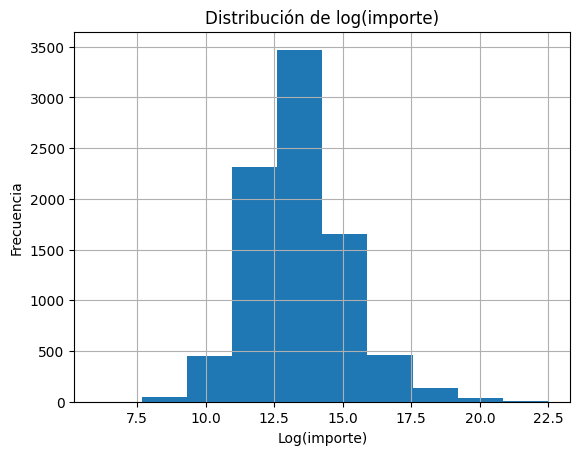

In [11]:
import numpy as np

df["log_importe"] = np.log(df["importe"])

import matplotlib.pyplot as plt

df["log_importe"].hist()

plt.xlabel("Log(importe)")
plt.ylabel("Frecuencia")
plt.title("Distribución de log(importe)")

plt.show()

Hagamos un diagrama de cajas para log(importe)

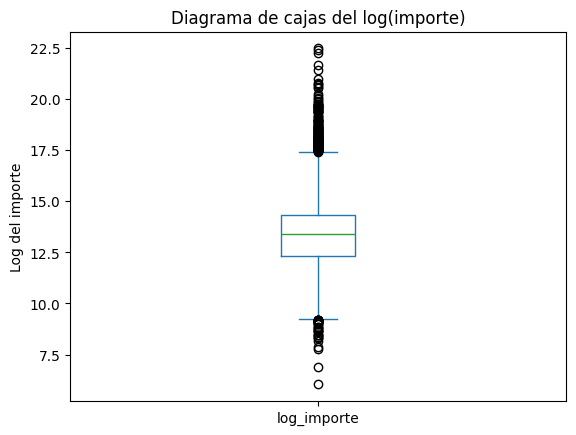

In [13]:
import matplotlib.pyplot as plt

df["log_importe"].plot(kind="box")

plt.ylabel("Log del importe")
plt.title("Diagrama de cajas del log(importe)")

plt.show()

Vemos que hay varios outliers. Encontremoslos:

In [14]:
q1 = df["log_importe"].quantile(0.25)
q3 = df["log_importe"].quantile(0.75)
iqr = q3 - q1

outliers = df[
    (df["log_importe"] < q1 - 1.5*iqr) |
    (df["log_importe"] > q3 + 1.5*iqr)
]

outliers

,ejercicio,ordencompra,fecha,importe,proveedor,dependencia,expediente,log_importe
1,2024,7497,2024-10-22,281500000.0,SOLUCIONES TURISTICAS SRL.,INSTITUTO DEL DEPORTE,Suministro 5536/2024,19.455643
128,2024,2042,2024-04-04,9000.0,FERRETERIA CENTRO,DIVISION DE ACCESIBILIDAD E INLCUSION,Suministro 1759/2024,9.104980
203,2024,1601,2024-03-18,126500000.0,INGENIERIA Y ARQUITECTURA SRL,SUBSECRETARIA DE ESPACIOS PUBLICOS,Suministro 1524/2024,18.655753
255,2024,494,2024-02-09,53444735.2,TALLERES B J IRRAZABAL S.A.,DEP. PROYECTOS Y OBRAS,Suministro 911/2024,17.794159
367,2024,2288,2024-04-12,5481.0,KBYTE COMPUTACION,INTENDENCIA,Suministro 2630/2024,8.609043
...,...,...,...,...,...,...,...,...
8438,2024,8971,2024-12-23,72289252.5,ELECTROMECANICA VALSOL S.R.L.,DEP. ELECTRICIDAD Y MECANICA,Expediente 7681/2024,18.096186
8454,2024,1869,2024-03-27,48000000.0,BAHIA AMBIENTAL SAPEM,TERMINAL OMNIBUS,Suministro 2216/2024,17.686712
8502,2024,7759,2024-10-31,121882416.0,COOPERATIVA ANGEL G BORLENGHI LTDA,SUBSECRETARIA DE MANTENIMIENTO,Suministro 7916/2024,18.618567
8515,2024,6896,2024-09-27,37663401.0,BAHIA COMUNICACIONES S.A.,OFIC PRESERVACION Y OPTIM DE LA CALIDAD AMBIENTAL,Suministro 6760/2024,17.444199


Veamos cuales son las dependencias con más órdenes de compra y cuáles son los proovedores más usados.

In [16]:
df['dependencia'].value_counts()

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA          733
INSTITUTO CULTURAL MUNICIPAL                667
SEC. DE SALUD                               604
INTENDENCIA                                 563
H.C.D.                                      278
                                           ... 
MERCADO MUNICIPAL                             1
NO USAR-DEPARTAMENTO PLANEAMIENTO URBANO      1
RECONOCIMIENTOS MEDICOS                       1
SUBDIRECCION DE PRESUPUESTO                   1
NO USAR-DEPARTAMENTO TERRITORIAL              1
Name: count, Length: 149, dtype: int64

In [17]:
df['proveedor'].value_counts()

proveedor
LA MOLIENDA                193
CODIMAT S.A.               172
AÑOS LUZ                   155
ECOBAHIA S.A.              102
FERRETERIA CENTRO           93
                          ... 
EDUARDO RAMOS                1
LEYTON TOMAS                 1
DROGUERIA APONOR S.A.        1
DISTRIBUIDORA EL CALDEN      1
ANDREU MILAGROS FATIMA       1
Name: count, Length: 1276, dtype: int64

# *Ingeniería de Variables*

Como tenemos muchas dependencias, nos quedamos con el top 25 (que cubre poco más que el 65% de las órdenes de compra) y el resto las agrupamos en 'Otras'.

In [26]:
# porcentaje que querés cubrir
porcentaje = 0.66   # 66%

# frecuencias relativas
freq = df["dependencia"].value_counts(normalize=True)

# porcentaje acumulado
acumulado = freq.cumsum()

# categorías que entran dentro del porcentaje elegido
top_dependencias = acumulado[acumulado <= porcentaje].index

# crear nueva variable agrupada
df["dependencia_agrupada"] = df["dependencia"].apply(
    lambda x: x if x in top_dependencias else "Otras"
)

# cantidad de dependencias conservadas
print(f"Cantidad de dependencias conservadas: {len(top_dependencias)}")

# porcentaje efectivamente cubierto
print(f"Porcentaje cubierto: {acumulado.loc[top_dependencias[-1]]:.2%}")

# frecuencias finales
print(df["dependencia_agrupada"].value_counts(normalize=True) * 100)

Cantidad de dependencias conservadas: 25
Porcentaje cubierto: 65.58%
dependencia_agrupada
Otras                                                34.419909
DEPARTAMENTO TALLERES Y MAESTRANZA                    8.564085
INSTITUTO CULTURAL MUNICIPAL                          7.792966
SEC. DE SALUD                                         7.056899
INTENDENCIA                                           6.577871
H.C.D.                                                3.248043
INSTITUTO DEL DEPORTE                                 2.909218
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                 2.792382
DIV. DE CONTROL Y ORDENAMIENTO URBANO                 2.535343
DIRECCION GENERAL DE EDUCACION                        2.360089
DEP. PROYECTOS Y OBRAS                                2.254936
SUBSECRETARIA DE AMBIENTE                             1.764225
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO               1.682440
SEC. DE OBRAS Y SERVICIOS PUBLICOS                    1.670756
SUBSECRETARIA DE PROTECCION 

Creamos la variable binaria "Proveedor frecuente". Si el proveedor aparece más de 12 veces diremos que es frecuente. Elegí el 12 como corte suponiendo que, de esta manera, se le estaría haciendo una compra al mes.

In [27]:
# contamos cuántas órdenes tiene cada proveedor
cant_ordenes = df["proveedor"].value_counts()

# creamos la variable binaria
df["Proveedor_Frecuente"] = df["proveedor"].apply(
    lambda x: "Si" if cant_ordenes[x] >= 12 else "No"
)

# verificamos resultados
print(df["Proveedor_Frecuente"].value_counts())

Proveedor_Frecuente
Si    4750
No    3809
Name: count, dtype: int64


Tambien creamos la variable mes y día.

In [28]:
# Aseguramos formato fecha
df["fecha"] = pd.to_datetime(df["fecha"])

# Número de mes
df["num_mes"] = df["fecha"].dt.month

# Día de la semana
# Lunes = 0, Domingo = 6
df["dia_semana"] = df["fecha"].dt.dayofweek

Recordemos que ya habíamos creado una nueva variable, log(importe).

# *Modelado*

Hagamos un modelo de regresión lineal que prediga log(importe).
Usamos las variables fabricadas antes. 

In [30]:
X = df[[
    "num_mes",
    "dia_semana",
    "dependencia_agrupada",
    "Proveedor_Frecuente"
]]

y = df["log_importe"]

In [31]:
X = pd.get_dummies(
    X,
    columns=["dependencia_agrupada", "Proveedor_Frecuente"],
    drop_first=True
)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
predicciones = modelo.predict(X_test)

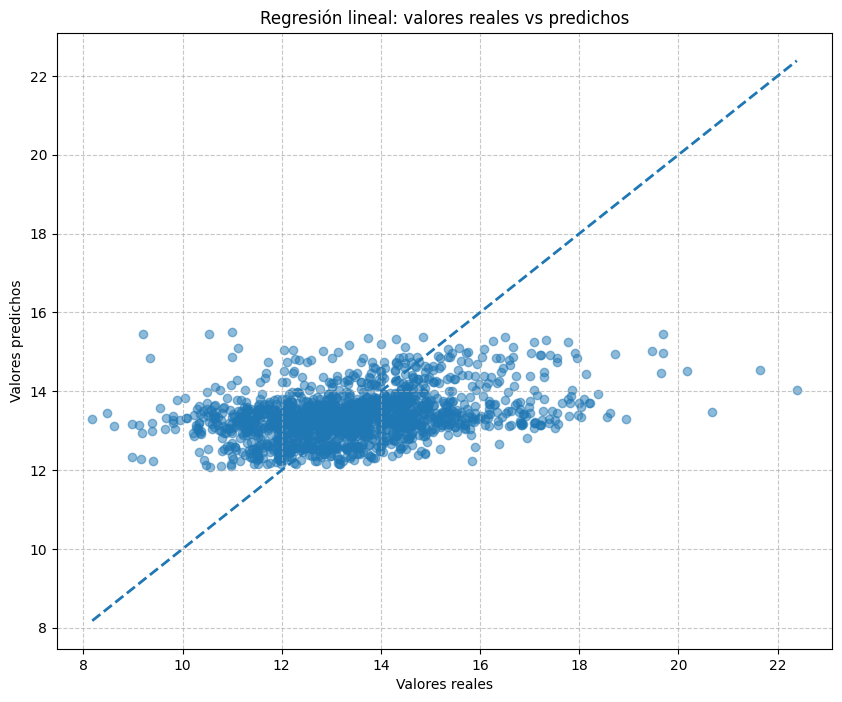

In [36]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, predicciones, alpha=0.5)

# línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal: valores reales vs predichos")

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# *Diagnóstico*

In [37]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, predicciones)

rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.1220498318461406
RMSE: 1.6001416445275256


Notemos que el R**2 es bastante bajo, por lo que decimos que no estamos prediciendo bien. No es necesariamente un error en el modelado, sino que probablemente estemos dejando de lado cosas que sean significativas para la predicción, como sucesos que hayan afectado a la ciudad, inflación, tipo de producto adquirido, etcetera. 

Notemos que el RMSE es de 1.6 aproximadamente. Considerando que trabajamos con el logaritmo, en promedio, las predicciones muestran una diferencia importante respecto a los valores reales. 

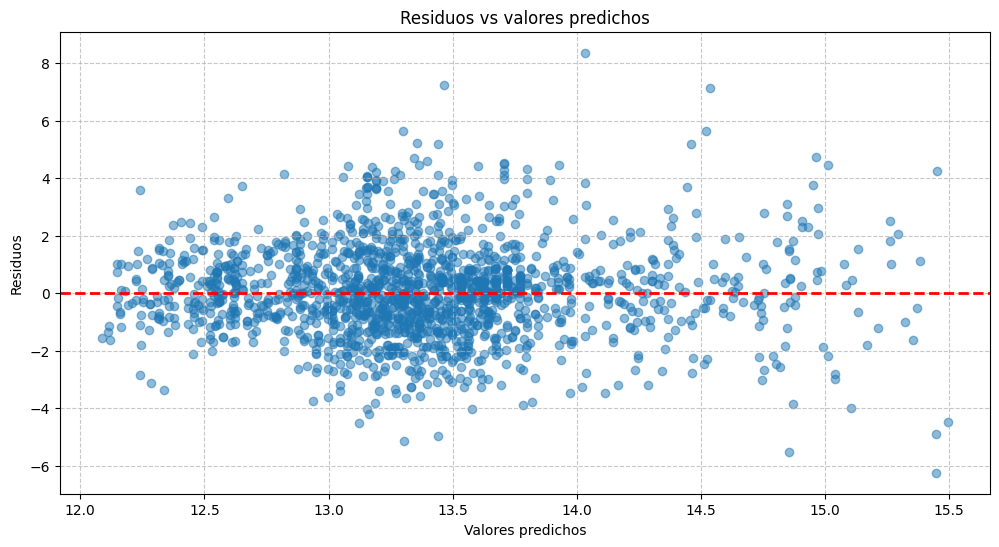

In [46]:
# Calculamos residuos
residuos = y_test - predicciones

# Graficamos residuos
plt.figure(figsize=(12,6))

plt.scatter(predicciones, residuos, alpha=0.5)

# línea horizontal en 0
plt.axhline(0, linestyle='--', color='red', linewidth=2)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs valores predichos")

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Notemos que, a simple vista, tenemos la mitad de nuestros puntos por encima de 0, y la otra mitad, por debajo. Por lo que tampoco podemos decir si modelo tiende a predecir más bajo o más alto que el dato real. 

# *Preguntas Bon o Bon*

*1. ¿En qué mes de 2024 se emitió la mayor cantidad de órdenes de compra?*

In [50]:
# Aseguramos formato fecha
df["fecha"] = pd.to_datetime(df["fecha"])

# Contamos órdenes por mes
ordenes_por_mes = df["fecha"].dt.month.value_counts().sort_index()

print(ordenes_por_mes)

fecha
1      362
2      849
3      678
4      738
5     1061
6      641
7      667
8      985
9      853
10     683
11     572
12     470
Name: count, dtype: int64


El mes que más órdenes de compras se hicieron fue Mayo, con 1061 de ellas. 

*2. ¿Cuál es la dependencia municipal con mayor gasto total acumulado en 2024?*

In [51]:
# Sumamos importes por dependencia
gasto_dependencia = df.groupby("dependencia")["importe"].sum()

# Dependencia con mayor gasto
dep_max = gasto_dependencia.idxmax()
monto_max = gasto_dependencia.max()

print(f"La dependencia con mayor gasto total fue:")
print(dep_max)

print(f"\nMonto total acumulado: ${monto_max:,.2f}")

La dependencia con mayor gasto total fue:
SUBSECRETARIA DE AMBIENTE

Monto total acumulado: $20,845,432,349.69


*3. ¿Cuál es el proveedor que más órdenes de compra recibió durante 2024?*

In [52]:
# Contamos órdenes por proveedor
ordenes_proveedor = df["proveedor"].value_counts()

# Proveedor con más órdenes
proveedor_max = ordenes_proveedor.idxmax()
cantidad_max = ordenes_proveedor.max()

print(f"El proveedor con más órdenes de compra fue:")
print(proveedor_max)

print(f"\nCantidad de órdenes: {cantidad_max}")

El proveedor con más órdenes de compra fue:
LA MOLIENDA

Cantidad de órdenes: 193


Dato de color: La Molienda es una distribuidora de panificados. 